In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from energy import (
  COLOR_SERIES,
  FIGSIZE,
  GRID_ALPHA,
  LINEWIDTH,
  LINEWIDTH_RAW,
  FONTSIZE_LEGEND,
  MULTI_SERIES_COLORS,
  finish_plot,
  new_figure,
)

In [11]:
cpus = pd.read_parquet("/mnt/7E442D59442D1585/md/paper/exp/cores-scaling/result/good/big/test/cpu.parquet")

In [12]:
cpus

,cores,v1,v2,v3,mean
0,0,874.334782,868.852590,863.408689,868.865354
1,1,489.329572,441.680970,487.727844,472.912795
2,2,336.462455,315.324816,304.961715,318.916329
3,3,247.080376,236.556032,234.416544,239.350984
4,4,239.141651,205.003515,208.661631,217.602266
5,5,169.196359,187.725204,185.730723,180.884095
6,6,172.520309,165.356805,175.749698,171.208938
7,7,162.420371,157.206460,162.549317,160.725383
8,8,160.125768,163.419102,154.159380,159.234750
9,9,152.867236,161.043525,161.399067,158.436609


In [13]:
plot = cpus.copy()
plot["n_cpus"] = plot["cores"] + 1
plot = plot.sort_values("n_cpus").reset_index(drop=True)

t1 = plot.loc[plot["n_cpus"] == 1, "mean"].iloc[0]
plot["speedup"] = t1 / plot["mean"]
for version in ["v1", "v2", "v3"]:
  plot[f"speedup_{version}"] = t1 / plot[version]

plot

,cores,v1,v2,v3,mean,n_cpus,speedup,speedup_v1,speedup_v2,speedup_v3
0,0,874.334782,868.852590,863.408689,868.865354,1,1.000000,0.993744,1.000015,1.006320
1,1,489.329572,441.680970,487.727844,472.912795,2,1.837263,1.775624,1.967179,1.781455
2,2,336.462455,315.324816,304.961715,318.916329,3,2.724430,2.582355,2.755461,2.849096
3,3,247.080376,236.556032,234.416544,239.350984,4,3.630089,3.516529,3.672979,3.706502
4,4,239.141651,205.003515,208.661631,217.602266,5,3.992906,3.633267,4.238295,4.163992
5,5,169.196359,187.725204,185.730723,180.884095,6,4.803437,5.135249,4.628389,4.678092
6,6,172.520309,165.356805,175.749698,171.208938,7,5.074883,5.036308,5.254488,4.943766
7,7,162.420371,157.206460,162.549317,160.725383,8,5.405900,5.349485,5.526906,5.345241
8,8,160.125768,163.419102,154.159380,159.234750,9,5.456506,5.426143,5.316792,5.636150
9,9,152.867236,161.043525,161.399067,158.436609,10,5.483994,5.683791,5.395221,5.383336


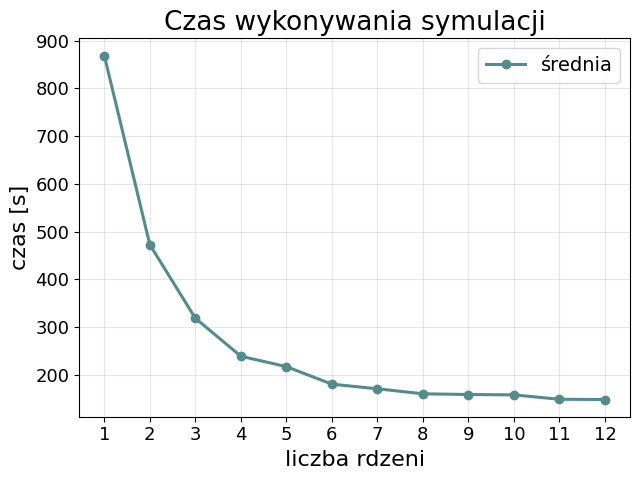

In [14]:
PLOT_DIR = "/mnt/7E442D59442D1585/md/paper/exp/cores-scaling/result/good/big/test/"

new_figure(multi_series=True)
# plt.plot(plot["n_cpus"], plot["v1"], linewidth=LINEWIDTH_RAW, marker="o", label="v1")
# plt.plot(plot["n_cpus"], plot["v2"], linewidth=LINEWIDTH_RAW, marker="o", label="v2")
# plt.plot(plot["n_cpus"], plot["v3"], linewidth=LINEWIDTH_RAW, marker="o", label="v3")
plt.plot(
  plot["n_cpus"],
  plot["mean"],
  color=COLOR_SERIES,
  linewidth=LINEWIDTH,
  marker="o",
  label="średnia",
)
plt.xticks(plot["n_cpus"])
finish_plot("liczba rdzeni", "czas [s]", "Czas wykonywania symulacji", PLOT_DIR, "cpu_time.png")

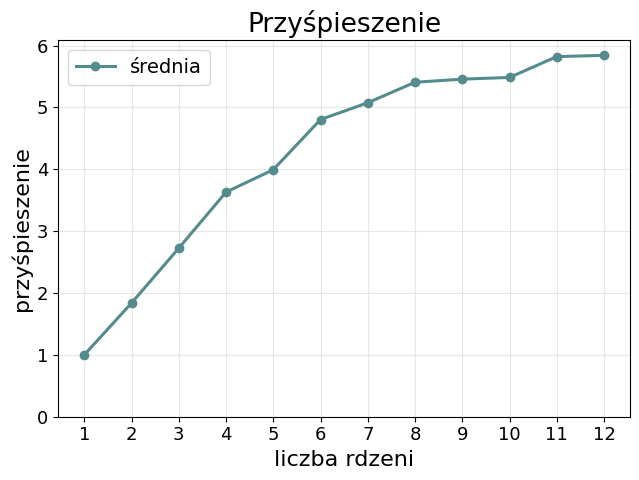

In [15]:
new_figure(multi_series=True)
# plt.plot(plot["n_cpus"], plot["speedup_v1"], linewidth=LINEWIDTH_RAW, marker="o", label="v1")
# plt.plot(plot["n_cpus"], plot["speedup_v2"], linewidth=LINEWIDTH_RAW, marker="o", label="v2")
# plt.plot(plot["n_cpus"], plot["speedup_v3"], linewidth=LINEWIDTH_RAW, marker="o", label="v3")
plt.plot(
  plot["n_cpus"],
  plot["speedup"],
  color=COLOR_SERIES,
  linewidth=LINEWIDTH,
  marker="o",
  label="średnia",
)
# plt.plot(
#   plot["n_cpus"],
#   plot["n_cpus"],
#   color="red",
#   linestyle="--",
#   linewidth=LINEWIDTH,
#   label="prawo Amdahla ($s = 0$)",
# )
plt.xticks(plot["n_cpus"])
plt.ylim(bottom=0)
finish_plot(
  "liczba rdzeni",
  "przyśpieszenie",
  "Przyśpieszenie",
  PLOT_DIR,
  "cpu_speedup.png",
)

In [16]:
summary = (
  plot[["n_cpus", "mean", "speedup"]]
  .rename(
    columns={
      "n_cpus": "liczba rdzeni",
      "mean": "średni czas [s]",
      "speedup": "średnie przyspieszenie",
    }
  )
  .astype({"liczba rdzeni": int})
)
summary

,liczba rdzeni,średni czas [s],średnie przyspieszenie
0,1,868.865354,1.000000
1,2,472.912795,1.837263
2,3,318.916329,2.724430
3,4,239.350984,3.630089
4,5,217.602266,3.992906
5,6,180.884095,4.803437
6,7,171.208938,5.074883
7,8,160.725383,5.405900
8,9,159.234750,5.456506
9,10,158.436609,5.483994


In [17]:
print(
  summary.style
  .format(
    {
      "liczba rdzeni": "{:d}",
      "średni czas [s]": "{:.3f}",
      "średnie przyspieszenie": "{:.3f}",
    }
  )
  .hide(axis="index")
  .to_latex(
    hrules=True,
    caption="Średni czas i przyspieszenie w zależności od liczby rdzeni.",
    label="tab:cpu_scaling",
    position="htbp",
  )
)

\begin{table}[htbp]
\caption{Średni czas i przyspieszenie w zależności od liczby rdzeni.}
\label{tab:cpu_scaling}
\begin{tabular}{rrr}
\toprule
liczba rdzeni & średni czas [s] & średnie przyspieszenie \\
\midrule
1 & 868.865 & 1.000 \\
2 & 472.913 & 1.837 \\
3 & 318.916 & 2.724 \\
4 & 239.351 & 3.630 \\
5 & 217.602 & 3.993 \\
6 & 180.884 & 4.803 \\
7 & 171.209 & 5.075 \\
8 & 160.725 & 5.406 \\
9 & 159.235 & 5.457 \\
10 & 158.437 & 5.484 \\
11 & 149.285 & 5.820 \\
12 & 148.736 & 5.842 \\
\bottomrule
\end{tabular}
\end{table}



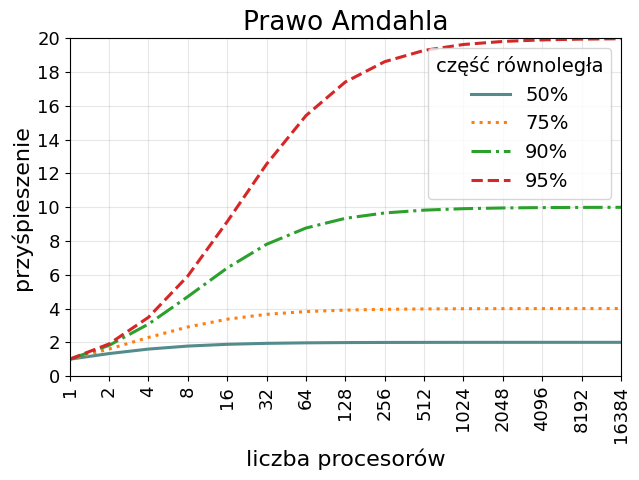

In [18]:
N = 2 ** np.arange(0, 15)
parallel_portions = [0.50, 0.75, 0.90, 0.95]
linestyles = ["-", ":", "-.", "--"]
colors = [COLOR_SERIES, *MULTI_SERIES_COLORS]

new_figure(multi_series=True)
for p, ls, color in zip(parallel_portions, linestyles, colors):
  s = 1 - p
  speedup = 1.0 / (s + p / N)
  plt.plot(N, speedup, color=color, linestyle=ls, linewidth=LINEWIDTH, label=f"{int(p * 100)}%")

plt.xscale("log", base=2)
plt.xticks(N, [str(n) for n in N], rotation=90)
plt.xlim(N[0], N[-1])
plt.ylim(0, 20)
plt.yticks(np.arange(0, 21, 2))
plt.legend(title="część równoległa", fontsize=FONTSIZE_LEGEND, title_fontsize=FONTSIZE_LEGEND)
finish_plot(
  "liczba procesorów",
  "przyśpieszenie",
  "Prawo Amdahla",
  PLOT_DIR,
  "amdahl.png",
  legend=False,
)